Import Libraries and Load Your Dataset

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your existing dataset
df = pd.read_csv("sales_data_with_discounts.csv")

 Preview the Data

In [9]:
df.head()

,Date,BU,Brand,Volume,Avg Price,Total Sales Value,Discount %,Discount Amount,Net Sales Value
0,2026-01-01,Mobiles,Xiaomi,4,57695.88,230783.52,20.0,46156.70,184626.82
1,2026-01-02,Mobiles,Apple,3,42911.61,128734.83,10.0,12873.48,115861.35
2,2026-01-03,FMCG,Jeera,4,168.93,675.72,10.0,67.57,608.15
3,2026-01-04,FMCG,Amul,3,29.25,87.75,0.0,0.00,87.75
4,2026-01-05,FMCG,Dabur,6,121.71,730.26,10.0,73.03,657.23


 Separate Numerical and Categorical Columns

In [10]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("Numerical Columns:", list(numerical_cols))
print("Categorical Columns:", list(categorical_cols))

Numerical Columns: ['Volume', 'Avg Price', 'Total Sales Value', 'Discount %', 'Discount Amount', 'Net Sales Value']
Categorical Columns: ['Date', 'BU', 'Brand']


Compute Descriptive Statistics

In [11]:
stats_df = pd.DataFrame({
    "Mean": df[numerical_cols].mean(),
    "Median": df[numerical_cols].median(),
    "Mode": df[numerical_cols].mode().iloc[0],
    "Standard Deviation": df[numerical_cols].std()
})
stats_df

,Mean,Median,Mode,Standard Deviation
Volume,6.253333,6.000,4.00,3.411992
Avg Price,14642.384178,2495.970,9000.00,21709.949825
Total Sales Value,93566.098867,12917.900,11.67,170646.619880
Discount %,8.700000,10.000,10.00,6.092183
Discount Amount,8632.556867,431.080,0.00,18704.649862
Net Sales Value,84933.542067,12432.365,11.09,156135.017610


Plot Histograms

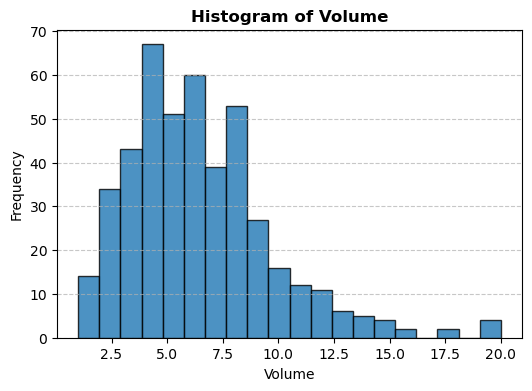

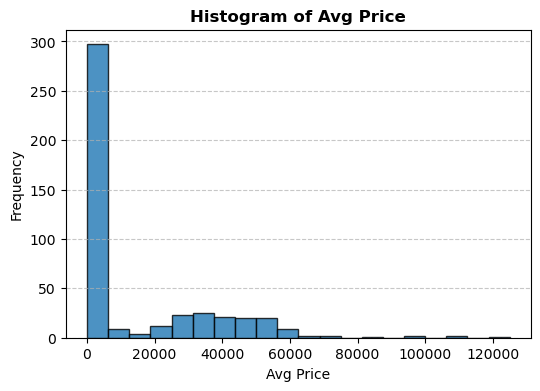

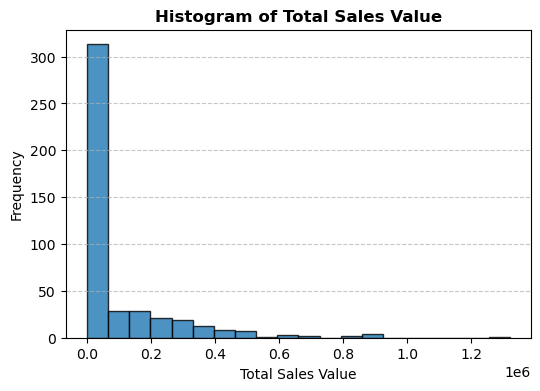

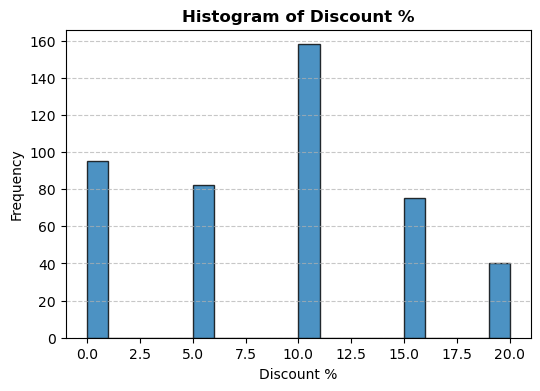

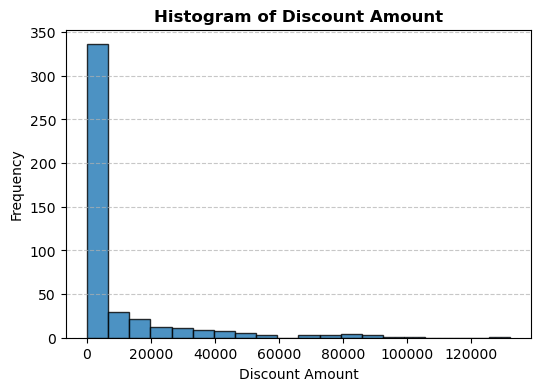

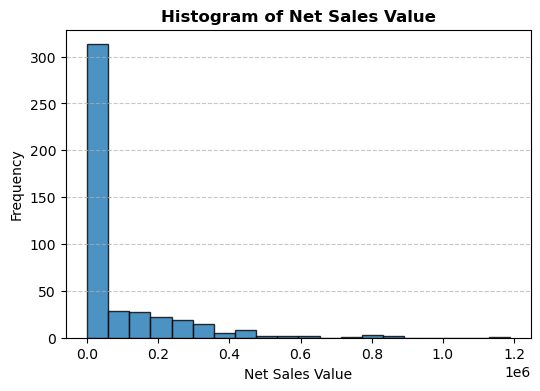

In [12]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=20, edgecolor='black', color='#1f77b4', alpha=0.8)
    plt.title(f'Histogram of {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

Plot Boxplots

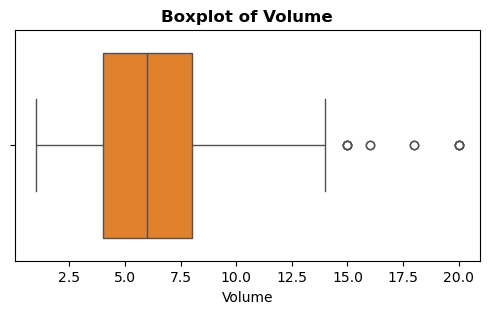

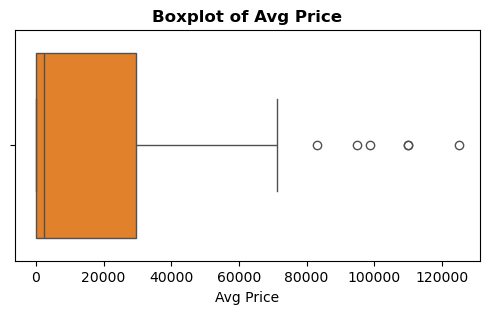

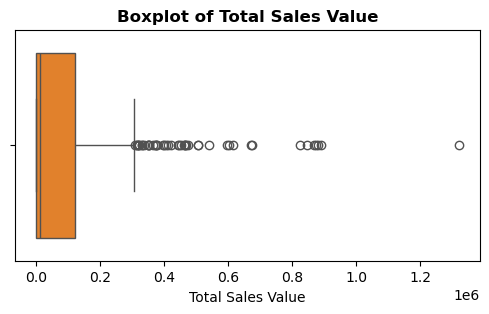

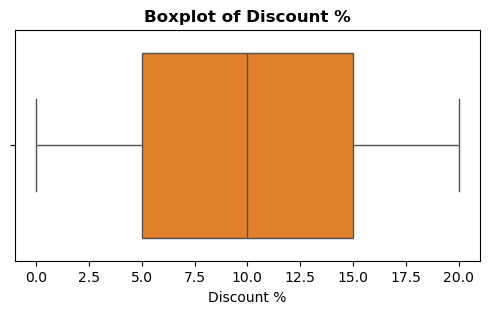

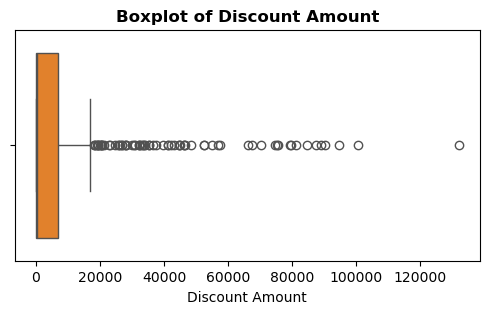

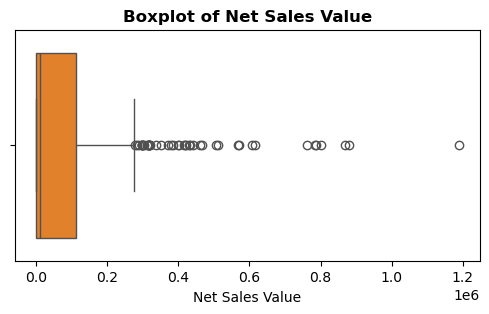

In [13]:
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col], color='#ff7f0e')
    plt.title(f'Boxplot of {col}', fontweight='bold')
    plt.show()

 Plot Bar Charts for Categorical Variables

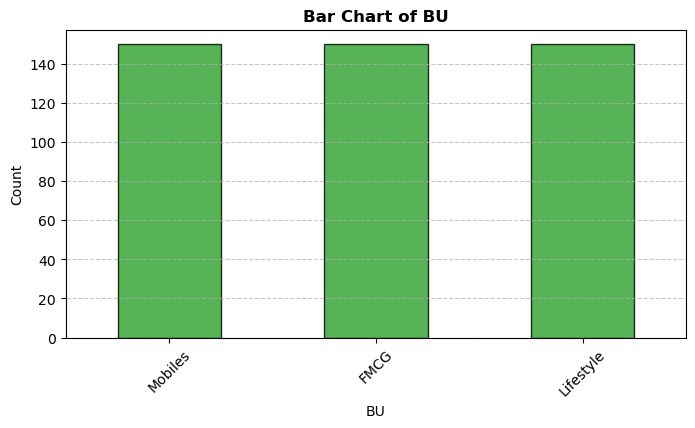

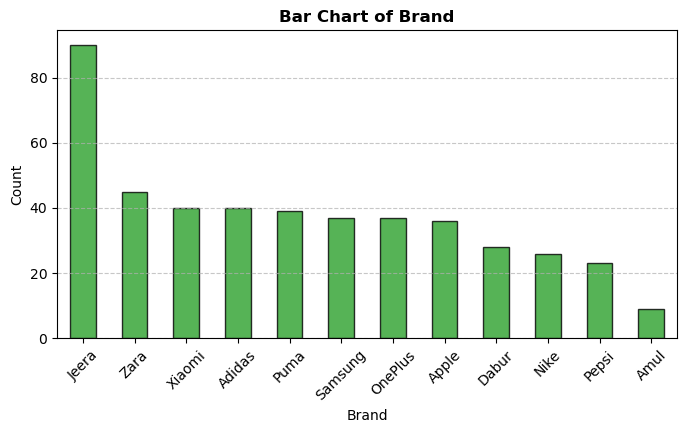

In [14]:
for col in categorical_cols:
    if col == 'Date':
        continue
    plt.figure(figsize=(8, 4))
    df[col].value_counts().plot(kind='bar', color='#2ca02c', edgecolor='black', alpha=0.8)
    plt.title(f'Bar Chart of {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

Check for Missing and Duplicate Values

In [15]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

print("\nDuplicate Records count:", df.duplicated().sum())

Missing Values in Each Column:
Date                 0
BU                   0
Brand                0
Volume               0
Avg Price            0
Total Sales Value    0
Discount %           0
Discount Amount      0
Net Sales Value      0
dtype: int64

Duplicate Records count: 0


Apply Dummy/One-Hot Encoding to Categorical Columns

In [16]:
df_encoded = pd.get_dummies(df, columns=['BU', 'Brand'], drop_first=True)
print("Encoded DataFrame columns:")
print(list(df_encoded.columns))

Encoded DataFrame columns:
['Date', 'Volume', 'Avg Price', 'Total Sales Value', 'Discount %', 'Discount Amount', 'Net Sales Value', 'BU_Lifestyle', 'BU_Mobiles', 'Brand_Amul', 'Brand_Apple', 'Brand_Dabur', 'Brand_Jeera', 'Brand_Nike', 'Brand_OnePlus', 'Brand_Pepsi', 'Brand_Puma', 'Brand_Samsung', 'Brand_Xiaomi', 'Brand_Zara']


Standardize Numerical Columns (Z-Score scaling)

In [17]:
df_scaled = df.copy()
for col in numerical_cols:
    mean_val = df[col].mean()
    std_val = df[col].std()
    df_scaled[col] = (df[col] - mean_val) / std_val

print("Standardized numerical columns statistics (Mean ≈ 0, Std Dev ≈ 1):")
df_scaled[numerical_cols].describe().round(2)

Standardized numerical columns statistics (Mean ≈ 0, Std Dev ≈ 1):


,Volume,Avg Price,Total Sales Value,Discount %,Discount Amount,Net Sales Value
count,450.00,450.00,450.00,450.00,450.00,450.00
mean,0.00,-0.00,0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.54,-0.67,-0.55,-1.43,-0.46,-0.54
25%,-0.66,-0.67,-0.54,-0.61,-0.46,-0.54
50%,-0.07,-0.56,-0.47,0.21,-0.44,-0.46
75%,0.51,0.69,0.17,1.03,-0.10,0.17
max,4.03,5.08,7.19,1.85,6.60,7.06
